<a href="https://colab.research.google.com/github/albvieiraa/Data-Analysis-Bootcamp-WoMakersCode/blob/main/exercicio_data_visualization_individual_maryllianvieira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício Prático - Data Visualization

Aluna: Maryllian de Albuquerque Vieira
Squad: Hedy Lamar

## Desafio Prático 1: Visualidando Dados Diferentes

**Descrição:** Neste desafio, suas alunas irão visualizar dados de diferentes formas utilizando Matplotlib, Seaborn e Plotly. Elas deverão criar gráficos que mostrem a distribuição dos dados, correlações entre variáveis e tendências.

Tarefas:

1. Carregar os dados de um arquivo CSV fornecido (saude.csv).

2. Criar um histograma da variável 'age' usando Matplotlib.

3. Criar um gráfico de dispersão mostrando a relação entre 'height' e 'weight' usando Seaborn.

4. Criar um gráfico interativo de barras mostrando a contagem de indivíduos por 'gender' usando Plotly.

In [ ]:
# Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Carregando os dados do arquivo

In [ ]:
# Importando o arquivo
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Womakerscode - bootcamp/Desafios_individual/base_dados/saude.csv'

# Carregando o arquivo CSV
df_saude = pd.read_csv(file_path)

# Exibindo o DataFrame
df_saude.head()

,id,age,height,weight,gender
0,1,23,170,70,M
1,2,34,160,65,F
2,3,45,175,80,M
3,4,25,165,55,F
4,5,36,180,90,M


In [ ]:
# Informações sobre o dataframe
df_saude.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      10 non-null     int64 
 1   age     10 non-null     int64 
 2   height  10 non-null     int64 
 3   weight  10 non-null     int64 
 4   gender  10 non-null     object
dtypes: int64(4), object(1)
memory usage: 528.0+ bytes


### Histograma da variável 'age' com Matplotlib

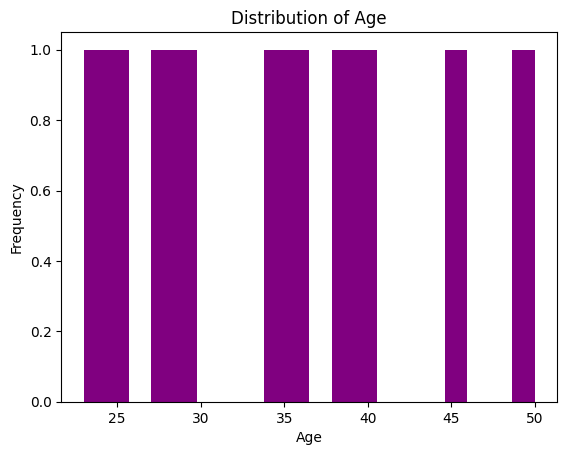

In [ ]:
plt.hist(df_saude['age'], bins=20, color='purple')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

É possível observar um histograma com distribuição simétrica, indicando uma distribuição homogênea. Deve levar-se em consideração a amostragem pequena.

### Gráfico de Dispersão com 'height' e 'weight' usando Seaborn

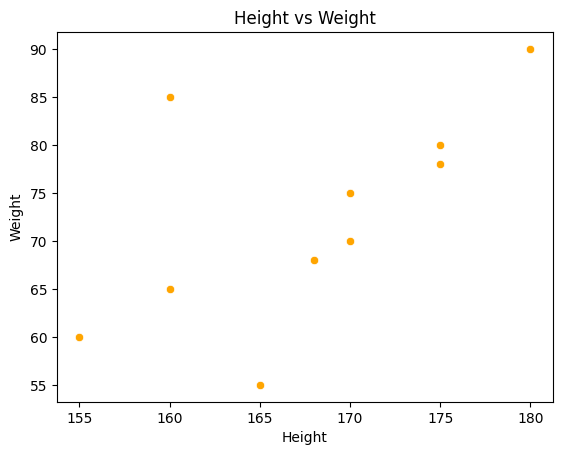

In [ ]:
sns.scatterplot(data=df_saude, x='height', y='weight', color='orange')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')
plt.show()

Observa-se que há uma tendência de aumento de peso(weight) a medida que a altura(height) também aumenta. Contudo, como os pontos não estão perfeitamente alinhados numa linha reta, pode indicar que há outros fatores que interferem nessa relação.

### Gráfico interativo de barras mostrando a contagem de indivíduos por 'gender' usando Plotly

In [ ]:
fig = px.bar(df_saude, x='gender', y='id', color='gender',
             title='Contagem de Indivíduos por Gênero')
fig.show()

A maior parte dos pacientes é do sexo feminino.

## Desafio Prático 2: Séries Temporais

**Descrição:** Neste desafio, suas alunas irão analisar uma série temporal de dados de vendas. Elas deverão criar gráficos que mostrem as vendas ao longo do tempo, identificar tendências e sazonalidades.

Tarefas:
1. Carregar os dados de um arquivo CSV fornecido (vendas.csv).
2. Criar um gráfico de linhas das vendas ao longo do tempo usando Matplotlib.
3. Criar um gráfico de decomposição sazonal usando Seaborn.
4. Criar um gráfico interativo que permita a exploração dos dados de vendas ao longo
do tempo usando Plotly.

In [ ]:
# Importando outras bibliotecas
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

### Carregando os dados

In [ ]:
file_path_2 = '/content/drive/MyDrive/Womakerscode - bootcamp/Desafios_individual/base_dados/vendas.csv'

# Carregando o arquivo CSV
df_vendas = pd.read_csv(file_path_2)

# Exibindo o DataFrame
df_vendas.head()

,date,sales
0,2023-01-01,100
1,2023-01-02,150
2,2023-01-03,200
3,2023-01-04,130
4,2023-01-05,180


In [ ]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    31 non-null     object
 1   sales   31 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 624.0+ bytes


### Gráfico de linhas das vendas ao longo do tempo usando Matplotlib

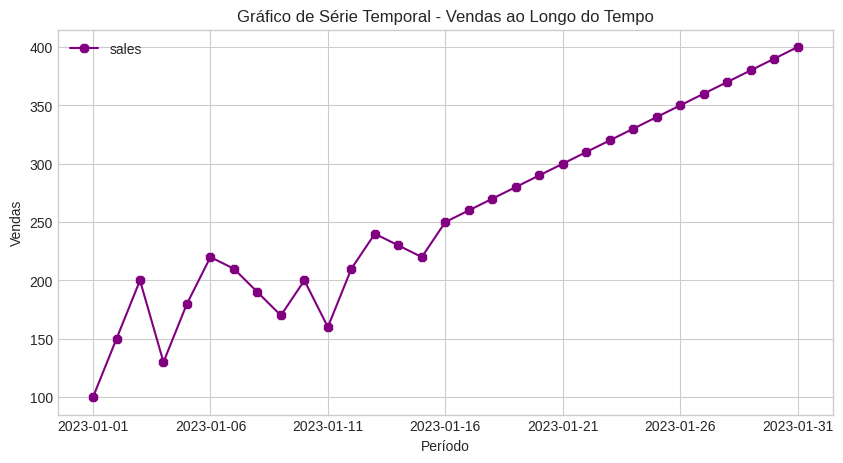

In [ ]:
# Trabalhar com uma cópia do dataframe para não modificar o original
df_copia = df_vendas.copy()
df_copia.set_index("date", inplace=True)

# Criar o gráfico de linha
ax = df_copia.plot(figsize=(10, 5), color="purple", marker="8")

# Definindo título e rótulos
ax.set_title("Gráfico de Série Temporal - Vendas ao Longo do Tempo")
ax.set_xlabel("Período")
ax.set_ylabel("Vendas")

# Mostrando o gráfico
plt.show()


### Gráfico de decomposição sazonal usando Seaborn

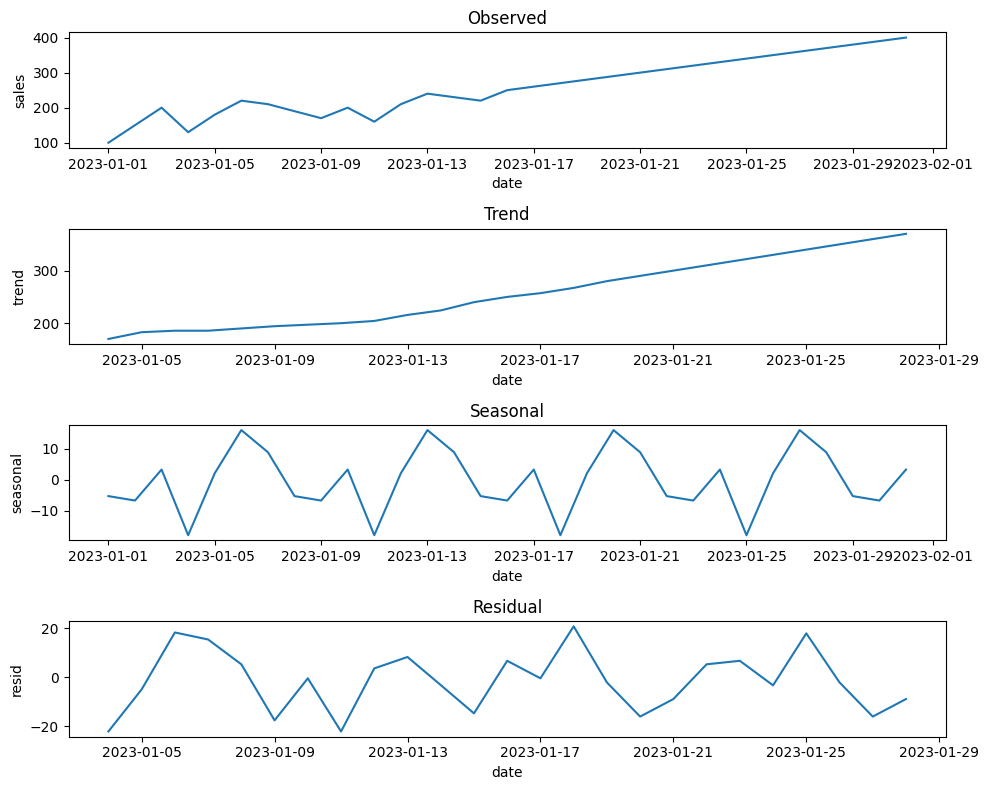

In [ ]:
# Decompor a série
decomposition = seasonal_decompose(df_vendas['sales'], model='additive', period=7)

# Criando os gráficos de decomposição
plt.figure(figsize=(10, 8))
plt.subplot(4, 1, 1)
sns.lineplot(data=decomposition.observed)
plt.title('Observed')

plt.subplot(4, 1, 2)
sns.lineplot(data=decomposition.trend)
plt.title('Trend')

plt.subplot(4, 1, 3)
sns.lineplot(data=decomposition.seasonal)
plt.title('Seasonal')

plt.subplot(4, 1, 4)
sns.lineplot(data=decomposition.resid)
plt.title('Residual')

plt.tight_layout()
plt.show()


### Gráfico interativo que permita a exploração dos dados de vendas ao longo do tempo usando Plotly.

In [ ]:
import plotly.express as px

# Criando o gráfico interativo de vendas ao longo do tempo
fig = px.line(df_vendas, x=df_vendas.index, y='sales', title='Vendas ao Longo do Tempo', labels={'x': 'Data', 'sales': 'Vendas'})
fig.show()
